
# TrappedAtomsSimulation_DipolePotential

Author: Paul Christ

Date: 04.11.2025


In [2]:
# Import
from TrappedAtomsSimulation.initialization import initialize_one_temp_gaussian_state, initialize_two_temp_gaussian_state
from TrappedAtomsSimulation.force_calculation import calculate_interaction_strength
from TrappedAtomsSimulation.force_calculation import pair_keops_fp
from TrappedAtomsSimulation.integrators import run_verlet_simulation_HO, solve_harmonic_analytical, run_verlet_simulation_general, run_verlet_simulation_dynamic
from TrappedAtomsSimulation.plot_utils import plot_energy_and_error, plot_thermalization
from TrappedAtomsSimulation.trap_potential_extended import calculate_single_beam_X_AXIS, calculate_single_beam_Y_AXIS, calculate_crossed_beam_dipole_potential, calculate_U0, calculate_crossed_trap_frequencies
#rom TrappedAtomsSimulation.verlet_list_force_calculation import run_verlet_list_simulation_general
from TrappedAtomsSimulation.initialization_rejection_sampling import prepare_one_temp_simulation_rejection, prepare_two_temp_simulation_rejection


import torch
import math
import time

In [3]:
### troch settings
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True
torch.backends.cudnn.benchmark = True

import torch._dynamo
torch._dynamo.config.capture_scalar_outputs = True


In [4]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
dtype = torch.float32
kB = 1.380649e-23  # J/K
c_light = 299_792_458.0 # m/s
pi = math.pi

## Trap

In [5]:
# Atommasse 87Rb
m_rb87 = 1.44160648e-25  # kg

# D1 Linie
omega_0_D1 = 2 * pi * 377.1074635e12 # rad/s
Gamma_D1 = 2 * pi * 5.746e6         # rad/s

# D2 Linie
omega_0_D2 = 2 * pi * 384.230484e12 # rad/s
Gamma_D2 = 2 * pi * 6.065e6         # rad/s

# Laserfrequenz
omega_L = 2 * pi * 280.179867e12    # rad/s




# Strahl 1 (X-Achse)
P_x = 5.18      # W
w0_x_SI = 41e-6   # m (41 µm)
zR_x_SI = 4.94e-3 # m (4.94 mm)

# Strahl 2 (Y-Achse)
P_y = 6.52      # W
w0_y_SI = 46e-6   # m (46 µm)
zR_y_SI = 6.21e-3 # m (6.21 mm)


# Gemeinsame Atom/Laser-Parameter
atom_laser_params = {
    "omega_L": omega_L,
    "omega_0_D1": omega_0_D1, "Gamma_D1": Gamma_D1,
    "omega_0_D2": omega_0_D2, "Gamma_D2": Gamma_D2
}



# Berechne U0 für Strahl 1
U0_1_SI = calculate_U0(P=P_x, w0=w0_x_SI, **atom_laser_params)

# Berechne U0 für Strahl 2
U0_2_SI = calculate_U0(P=P_y, w0=w0_y_SI, **atom_laser_params)

U0_1_in_uK = (U0_1_SI / kB) * 1e6
U0_2_in_uK = (U0_2_SI / kB) * 1e6

print("--- Berechnete Potentialtiefen (U0) ---")
print(f"  Strahl 1: {U0_1_in_uK:.1f} µK ")
print(f"  Strahl 2: {U0_2_in_uK:.1f} µK ")

trap_frequencies = calculate_crossed_trap_frequencies(
    U0_1=U0_1_SI, w0_1=w0_x_SI, zR_1=zR_x_SI,
    U0_2=U0_2_SI, w0_2=w0_y_SI, zR_2=zR_y_SI,
    m=m_rb87
)

print("\n--- Berechnete Frequenzen (basierend auf U0) ---")
print(f"  f_x: {trap_frequencies['freq_x_hz']:.0f} Hz")
print(f"  f_y: {trap_frequencies['freq_y_hz']:.0f} Hz")
print(f"  f_z: {trap_frequencies['freq_z_hz']:.0f} Hz")
print(f"  f_mean: {trap_frequencies['freq_mean_hz']:.0f} Hz")


--- Berechnete Potentialtiefen (U0) ---
  Strahl 1: -294.8 µK 
  Strahl 2: -294.8 µK 

--- Berechnete Frequenzen (basierend auf U0) ---
  f_x: 1163 Hz
  f_y: 1305 Hz
  f_z: 1747 Hz
  f_mean: 1384 Hz


## One group

--- Starte Simulation mit N=12062 Teilchen ---
--- Skalierung basierend auf T = 1.00e-06 K ---
Längenskala L0: 1.34e-06 m, Energieskala E0: 1.38e-29 J, Zeitskala T0: 1.37e-04 s
Initialisiere 12062 Teilchen bei T = 1.00e-06 K
--- Initialisierung abgeschlossen ---

--- Skalierung basierend auf T_ref = 1.00e-06 K ---
Längenskala L0: 1.34e-06 m, Energieskala E0: 1.38e-29 J...
Verwende Bounding Box basierend auf T = 1.00e-06 K.
Initialisiere Gruppe (N=12062, T=1.00e-06 K)...
  -> Starte Rejection Sampling für 12062 Teilchen (T/T_ref = 1.00)...
  -> Sampling beendet. Akzeptanzrate: 0.06%
Dimensionslose Paar-Parameter: r=0.03912, c=1.623e-03
--- Ein-Temperatur-Initialisierung abgeschlossen ---

Starte Simulation mit  Dipolfalle
Integration 100% | ETA: 0 min 0 s
Integration abgeschlossen.
Simulation abgeschlossen in 7.93 Sekunden.


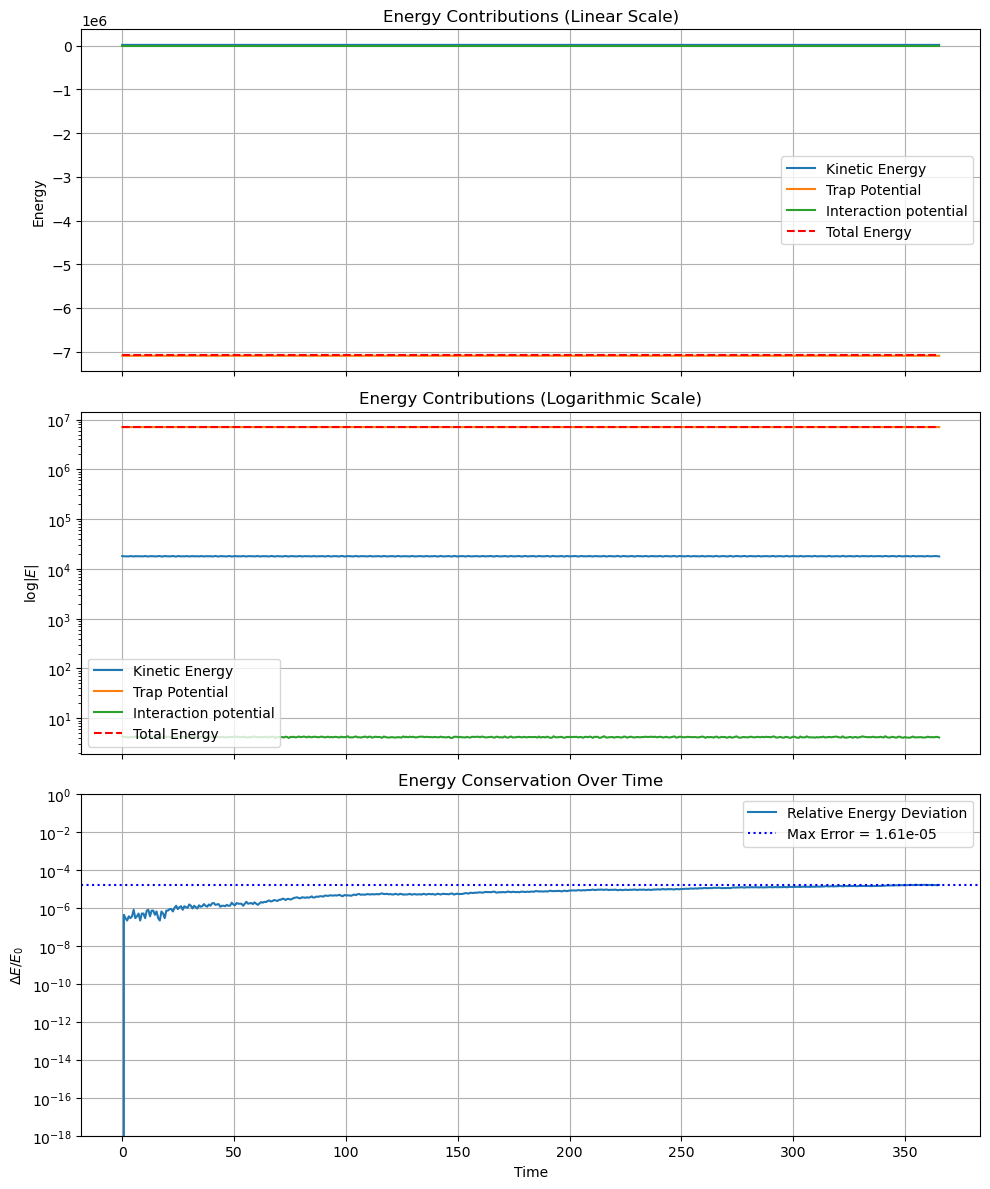

tensor(1.6112e-05, device='cuda:0')

In [6]:
N_PARTICLES = 12062         
TEMPERATURE_K = 1e-6       
SIMULATION_TIME_S = 0.05    # 
TIMESTEP_S = 1e-4            # 
SUBSTEPS = 5

 
TRAP_FREQUENCIES_HZ = (trap_frequencies['freq_x_hz'],trap_frequencies['freq_y_hz'],trap_frequencies['freq_z_hz'])

# ---  Physikalische Wechselwirkungsparameter ---

r0_phys,C_phys = calculate_interaction_strength(10)

print(f"--- Starte Simulation mit N={N_PARTICLES} Teilchen ---")
# ---  Initialisierung ---
# Bestimmt L0, E0, T0, q0, p0, r_dimless, c_dimless
sim_init_params = initialize_one_temp_gaussian_state(
    n_particles=N_PARTICLES,
    temp_k=TEMPERATURE_K,
    omega_phys_hz=TRAP_FREQUENCIES_HZ, # Verwendet harmonische Freq. für Start
    t_end_s=SIMULATION_TIME_S,
    dt_s=TIMESTEP_S,
    r0_phys=r0_phys,
    C_phys=C_phys/100,
    precision=torch.float32,
    device=device
)
 

# Skalierungsfaktoren  
L0 = sim_init_params['L0_m']
E0 = sim_init_params['E0_J']
T0 = sim_init_params['T0_s']
 

# a) Parameter für die Dipolfalle
trap_params_extended = {
    "P_x": P_x, "P_y": P_y,
    "w0_x": w0_x_SI, "w0_y": w0_y_SI,
    "s0_x": zR_x_SI, "s0_y": zR_y_SI,
    "omega_L": omega_L,
    "omega_0_D1": omega_0_D1, "Gamma_D1": Gamma_D1,
    "omega_0_D2": omega_0_D2, "Gamma_D2": Gamma_D2,
    "L0": L0,
    "E0": E0
}

sim_init_params_rejection_sampling = prepare_one_temp_simulation_rejection(
    n_particles =N_PARTICLES,
    temp_k=TEMPERATURE_K,
    omega_phys_hz=TRAP_FREQUENCIES_HZ,
    t_end_s=SIMULATION_TIME_S,
    dt_s=TIMESTEP_S,
    r0_phys=r0_phys,
    C_phys=C_phys/100,
    trap_force_func=calculate_crossed_beam_dipole_potential,
    trap_params=trap_params_extended,
    precision=torch.float32,
    device=device
)



# b) Parameter für die Paar-Wechselwirkung  
pair_params = sim_init_params_rejection_sampling['pair_force_params']

# c) Parameter für den Integrator  
integrator_params = {
    "t_values": sim_init_params_rejection_sampling['t_values'],
    "q0": sim_init_params_rejection_sampling['q0'],
    "p0": sim_init_params_rejection_sampling['p0'],
    "precision_type": sim_init_params_rejection_sampling['precision_type'],
    "device": sim_init_params_rejection_sampling['device'],
    "substeps": SUBSTEPS,
}

# --- 6. Simulationsaufruf ---
print("Starte Simulation mit  Dipolfalle")
start_time = time.perf_counter()

results = run_verlet_simulation_general(
    trap_force_func=calculate_crossed_beam_dipole_potential,
    trap_force_params=trap_params_extended,

    pair_force_func=pair_keops_fp,
    pair_force_params=pair_params,

    **integrator_params
)

duration = time.perf_counter() - start_time
print(f"Simulation abgeschlossen in {duration:.2f} Sekunden.")

# --- 7. Ergebnisse plotten ---
plot_energy_and_error(
    results['times'],
    results['kinetic_energy'],
    results['potential_energy_trap'],
    results['potential_energy_pair']
)


